In [1]:
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.behavior.wheel import velocity
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell

c:\Users\debot\miniconda3\envs\info-decom\lib\site-packages\ibllib\atlas\__init__.py:205: DeprecationWarning: ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use this module instead
  warnings.warn('ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use '


In [2]:
## Standard python imports and IDTxL

import numpy as np
from idtxl.active_information_storage import ActiveInformationStorage
from idtxl.data import Data
from idtxl.bivariate_pid import BivariatePID
from idtxl.multivariate_pid import MultivariatePID
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import seaborn as sns
import itertools

In [3]:
import elephant as elph
import quantities as pq

In [4]:
# solvers -> BROJA pid, tartu PID solvers

In [5]:
# generate data similar to IBL
# 100ms of data /

In [4]:
def computepid_multipleneurons(sources, targets, data, lags=[1, 1]):
    """computes the BROJA partial information decomposition

    Args:
        data (IDTxl data array): Data array containing Channels x Trials X Timepoints
        lags (list, optional): Lag to compute the pid for. Defaults to [1,1].
        sources (np.array): array with sources; X1 and X2
        targets (np.array): array with targets; Y

    """

    PID_storage = np.zeros((len(targets), len(sources[0]), 4))
    settings_tartu = {"pid_estimator": "TartuPID", "lags_pid": lags}

    for index, target in tqdm(enumerate(targets)):
        pid_info = []
        target = int(target)
        for r in tqdm(range(len(sources[index])), leave=False):
            S = sources[index][r]
            partial_decomposition = BivariatePID()
            result = partial_decomposition.analyse_single_target(
                data=data, settings=settings_tartu, target=target, sources=S
            )
            pid_info.append(
                [
                    result.get_single_target(target)["unq_s1"],
                    result.get_single_target(target)["unq_s2"],
                    result.get_single_target(target)["shd_s1_s2"],
                    result.get_single_target(target)["syn_s1_s2"],
                ]
            )
        pid_info = np.asarray(pid_info)
        PID_storage[index, :, :] = pid_info
    return PID_storage


def computepid(Y, X1, X2, lags=[0, 0]):
    """compute broja pid for a single target with 2 sources

    Args:
        Y (np.array): target
        X1 (np.array): source 1
        X2 (np.array): source 2
        lags (list, optional): Lags to consider. Defaults to [0,0].
    """
    data = np.vstack([Y, X1, X2])
    data = Data(data, order="ps")
    settings_tartu = {"pid_estimator": "TartuPID", "lags_pid": lags}
    pid = BivariatePID()
    result = pid.analyse_single_target(
        data=data, settings=settings_tartu, lags=lags, target=0, sources=[1, 2]
    )
    return [
        result.get_single_target(0)["unq_s1"],
        result.get_single_target(0)["unq_s2"],
        result.get_single_target(0)["shd_s1_s2"],
        result.get_single_target(0)["syn_s1_s2"],
    ]

In [5]:
def binneddata(spike_times, start_time, end_time, bin_length, binarize=True):
    # Create bins from start_time to end_time with the specified bin_length
    bins = np.arange(start_time, end_time + bin_length, bin_length)

    # Use np.histogram to count the number of spikes in each bin
    spike_counts, _ = np.histogram(spike_times, bins=bins)

    if binarize:
        spike_counts[spike_counts >= 1] = 1
        return spike_counts
    else:
        return spike_counts

In [6]:
s1 = elph.spike_train_generation.homogeneous_poisson_process(
    15 * pq.Hz, 0 * pq.ms, 500 * pq.ms
).magnitude
s2 = elph.spike_train_generation.homogeneous_poisson_process(
    25 * pq.Hz, 0 * pq.ms, 500 * pq.ms
).magnitude

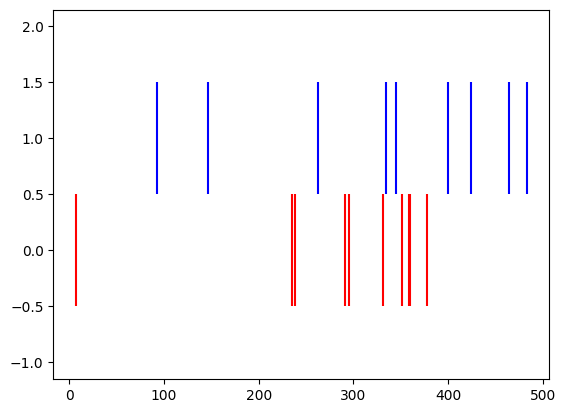

In [7]:
plt.eventplot(s1, lineoffsets=0, color="r")
plt.eventplot(s2, lineoffsets=1, colors="b")

In [8]:
x1 = binneddata(s1, 0, 500, 10, binarize=False)
x2 = binneddata(s2, 0, 500, 10, binarize=False)

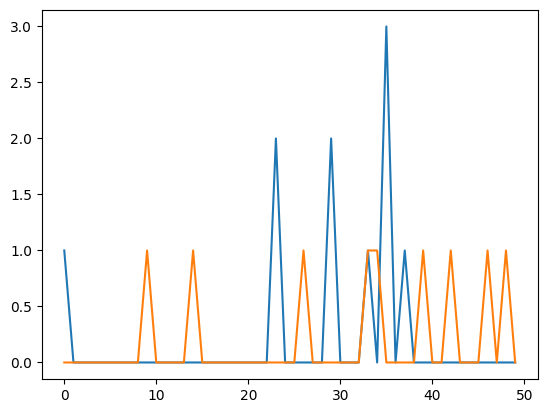

In [9]:
plt.plot(x1)
plt.plot(x2)

In [10]:
# generate bunch of spikes with similar firing rates
def generate_spike_pairs(lambda1, lambda2, total=15, t_start=0, t_end=500):
    spike_1_collection = []
    spike_2_collection = []
    for x in range(total):
        spike_1_collection.append(
            elph.spike_train_generation.homogeneous_poisson_process(
                lambda1 * pq.Hz, t_start * pq.ms, t_end * pq.ms
            ).magnitude
        )
        spike_2_collection.append(
            elph.spike_train_generation.homogeneous_poisson_process(
                lambda2 * pq.Hz, t_start * pq.ms, t_end * pq.ms
            ).magnitude
        )
    return spike_1_collection, spike_2_collection

In [114]:
s1_collection, s2_collection = generate_spike_pairs(15, 25,total=150)

In [128]:
t_start = 0
t_end = 100
bin_size = 50

s1_binned = np.zeros((len(s1_collection), int((t_end - t_start) / bin_size)), dtype=np.int32)
s2_binned = np.zeros((len(s2_collection), int((t_end - t_start) / bin_size)), dtype=np.int32)

for x in range(len(s1_collection)):
    a1 = binneddata(s1_collection[x], t_start, t_end, bin_size, binarize=False)
    a2 = binneddata(s2_collection[x], t_start, t_end, bin_size, binarize=False)
    s1_binned[x, :] = a1
    s2_binned[x, :] = a2

In [129]:
# Neuron-3: XOR
s3_binned = np.logical_xor(s1_binned, s2_binned)
s4_binned = s1_binned  # all shared, nothing unique

Text(0.5, 1.0, 'Neuron 3 = XOR(N1, N2)')

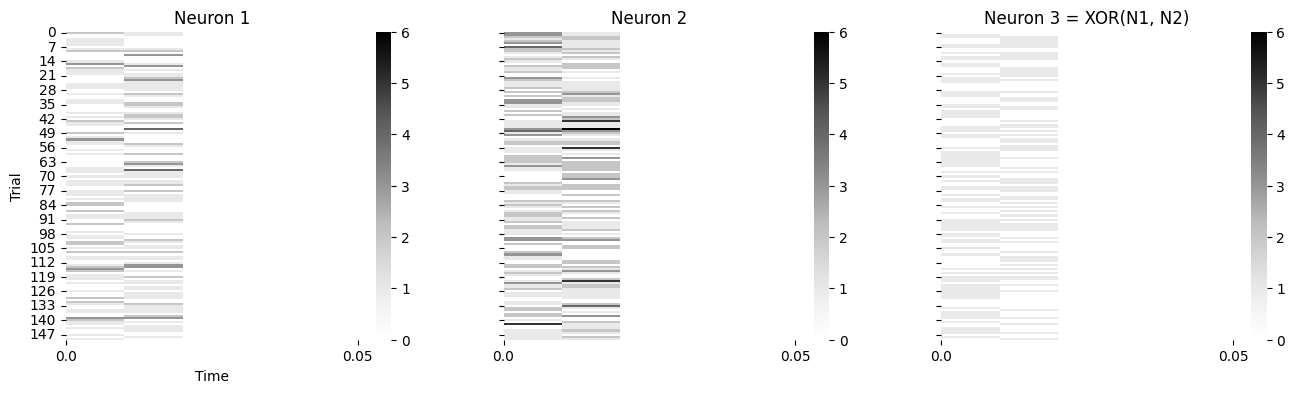

In [130]:
fig, ax = plt.subplots(ncols=3, figsize=(16, 4), sharex=True, sharey=True)
vmax = np.max([np.max(s1_binned), np.max(s2_binned)])
sns.heatmap(s1_binned, cmap="Greys", ax=ax[0], vmax=vmax, vmin=0)
sns.heatmap(s2_binned, cmap="Greys", ax=ax[1], vmax=vmax, vmin=0)
sns.heatmap(s3_binned, cmap="Greys", ax=ax[2], vmax=vmax, vmin=0)
ax[0].set_xticks(np.arange(0, 10, 5))
ax[0].set_xticklabels(labels=np.arange(0, 10, 5) / 100)
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Trial")
ax[0].set_title("Neuron 1")
ax[1].set_title("Neuron 2")
ax[2].set_title("Neuron 3 = XOR(N1, N2)")

In [131]:
neural_data = np.stack([s1_binned, s2_binned, s3_binned])
pid_data = Data(neural_data, dim_order="prs", normalise=False)

Adding data with properties: 3 processes, 2 samples, 150 replications
overwriting existing data


In [132]:
pid = BivariatePID()
settings_tartu = {"pid_estimator": "TartuPID", "lags_pid": [0, 0]}


results_tartu = pid.analyse_single_target(
    settings=settings_tartu, data=pid_data, target=2, sources=[0, 1]
)


unq information s1: 0.13991113, s2: 0.00000000
shd information: 0.01322320, syn information: 0.84683362


In [102]:
pid = BivariatePID()

alphabet = np.unique(neural_data)
settings_sydney = {
    "alph_s1": len(alphabet),
    "alph_s2": len(alphabet),
    "alph_t": len(alphabet),
    "max_unsuc_swaps_row_parm": 60,
    "num_reps": 63,
    "max_iters": 1000,
    "pid_estimator": "SydneyPID",
    "lags_pid": [0, 0],
}

results_sydney = pid.analyse_single_target(
    settings=settings_sydney, data=pid_data, target=2, sources=[0, 1]
)

d:\personal\phd\code\idtxl\idtxl\estimators_pid.py:262: RuntimeWarning: divide by zero encountered in divide
  np.longdouble(max_prob), np.divide(np.longdouble(1), np.longdouble(rep))



unq information s1: -0.00000000, s2: 0.03337565
shd information: 0.01910504, syn information: 0.94739107


In [90]:
# a) Generate test data

n = 5
alph = 2

list_x = []
list_y = []
list_z = []
for i in range(5):
    x = np.random.randint(0, alph, n)
    y = np.random.randint(0, alph, n)
    z = np.logical_xor(x, y).astype(int)
    list_x.append(x)
    list_y.append(y)
    list_z.append(z)

list_x = np.asarray(list_x, dtype=int)
list_y = np.asarray(list_y, dtype=int)
list_z = np.asarray(list_z, dtype=int)

Text(0.5, 1.0, 'Neuron 3 = XOR(N1, N2)')

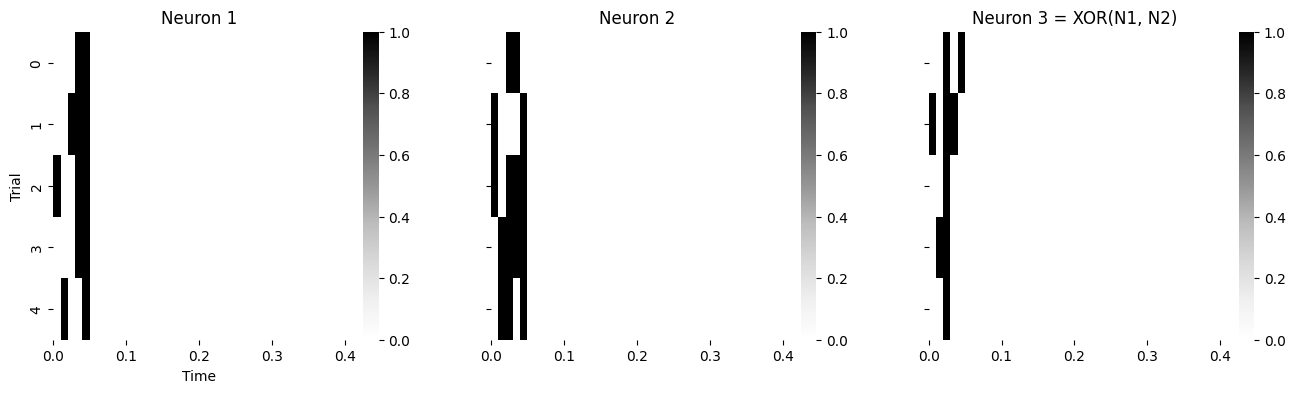

In [91]:
fig, ax = plt.subplots(ncols=3, figsize=(16, 4), sharex=True, sharey=True)
vmax = np.max([np.max(list_x), np.max(list_y)])
sns.heatmap(list_x, cmap="Greys", ax=ax[0], vmax=vmax, vmin=0)
sns.heatmap(list_y, cmap="Greys", ax=ax[1], vmax=vmax, vmin=0)
sns.heatmap(list_z, cmap="Greys", ax=ax[2], vmax=vmax, vmin=0)
ax[0].set_xticks(np.arange(0, 50, 10))
ax[0].set_xticklabels(labels=np.arange(0, 50, 10) / 100)
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Trial")
ax[0].set_title("Neuron 1")
ax[1].set_title("Neuron 2")
ax[2].set_title("Neuron 3 = XOR(N1, N2)")

In [93]:
dummydata = np.stack([list_x, list_y, list_z])
print(dummydata.shape)

(3, 5, 5)


In [94]:
data = Data(dummydata, "prs", normalise=False)

# b) Initialise analysis object and define settings for both PID estimators
pid = BivariatePID()
settings_tartu = {"pid_estimator": "TartuPID", "lags_pid": [0, 0]}
settings_sydney = {
    "alph_s1": alph,
    "alph_s2": alph,
    "alph_t": alph,
    "max_unsuc_swaps_row_parm": 60,
    "num_reps": 63,
    "max_iters": 1000,
    "pid_estimator": "SydneyPID",
    "lags_pid": [0, 0],
}

# c) Run Tartu estimator
results_tartu = pid.analyse_single_target(
    settings=settings_tartu, data=data, target=2, sources=[0, 1]
)

# d) Run Sydney estimator
pid = BivariatePID()
results_sydney = pid.analyse_single_target(
    settings=settings_sydney, data=data, target=2, sources=[0, 1]
)

# e) Print results to console
print("\nLogical XOR")
print("Estimator            Sydney\t\tTartu\t\tExpected\n")
print(
    "Uni s1               {0:.4f}\t\t{1:.4f}\t\t{2:.2f}".format(
        results_sydney.get_single_target(2)["unq_s1"],
        results_tartu.get_single_target(2)["unq_s1"],
        0,
    )
)
print(
    "Uni s2               {0:.4f}\t\t{1:.4f}\t\t{2:.2f}".format(
        results_sydney.get_single_target(2)["unq_s2"],
        results_tartu.get_single_target(2)["unq_s2"],
        0,
    )
)
print(
    "Shared s1_s2         {0:.4f}\t\t{1:.4f}\t\t{2:.2f}".format(
        results_sydney.get_single_target(2)["shd_s1_s2"],
        results_tartu.get_single_target(2)["shd_s1_s2"],
        0,
    )
)
print(
    "Synergy s1_s2        {0:.4f}\t\t{1:.4f}\t\t{2:.2f}".format(
        results_sydney.get_single_target(2)["syn_s1_s2"],
        results_tartu.get_single_target(2)["syn_s1_s2"],
        1,
    )
)

Adding data with properties: 3 processes, 5 samples, 5 replications
overwriting existing data

unq information s1: 0.02789494, s2: -0.00000000
shd information: 0.00759648, syn information: 0.90719177

unq information s1: 0.02789494, s2: 0.00000000
shd information: 0.00759647, syn information: 0.90719177

Logical XOR
Estimator            Sydney		Tartu		Expected

Uni s1               0.0279		0.0279		0.00
Uni s2               0.0000		-0.0000		0.00
Shared s1_s2         0.0076		0.0076		0.00
Synergy s1_s2        0.9072		0.9072		1.00


d:\personal\phd\code\idtxl\idtxl\estimators_pid.py:262: RuntimeWarning: divide by zero encountered in divide
  np.longdouble(max_prob), np.divide(np.longdouble(1), np.longdouble(rep))
